In [94]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score,accuracy_score
import joblib

# 1. Load the dataset
df = pd.read_csv('/kaggle/input/renewable-hydrogen-production-dataset/renewable_hydrogen_dataset_2535.csv')

# 2. Select features and target
features = [
    'Solar_Irradiance_kWh/m²/day',
    'Temperature_C',
    'Wind_Speed_m/s',
    'PV_Power_kW',
    'Wind_Power_kW',
    'Electrolyzer_Efficiency_%'
]
target = 'Hydrogen_Production_kg/day'

# 3. Drop rows with missing values
df = df.dropna(subset=features + [target])

X = df[features]
y = df[target]

# 4. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Evaluate the model
y_pred = model.predict(X_test)
print('MAE:', mean_absolute_error(y_test, y_pred))
print('R²:', r2_score(y_test, y_pred))

# 7. Save the model
joblib.dump(model, 'hydrogen_production_model.pkl')


MAE: 3.72179549927397
R²: -0.0068381066191973705


['hydrogen_production_model.pkl']

In [95]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf.predict(X_test)
print('MAE:', mean_absolute_error(y_test, y_pred))
print('R²:', r2_score(y_test, y_pred))

MAE: 3.7635108481262325
R²: -0.04108617095068867


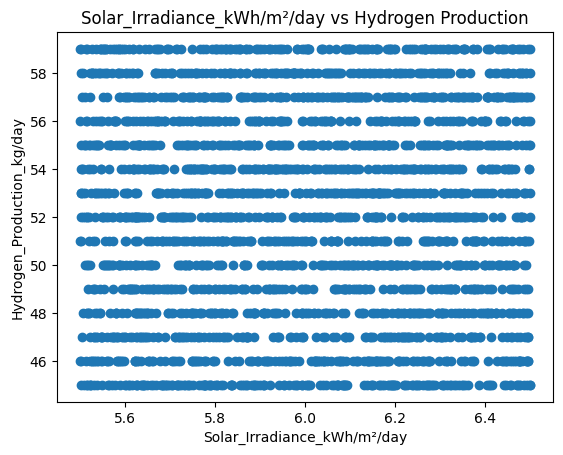

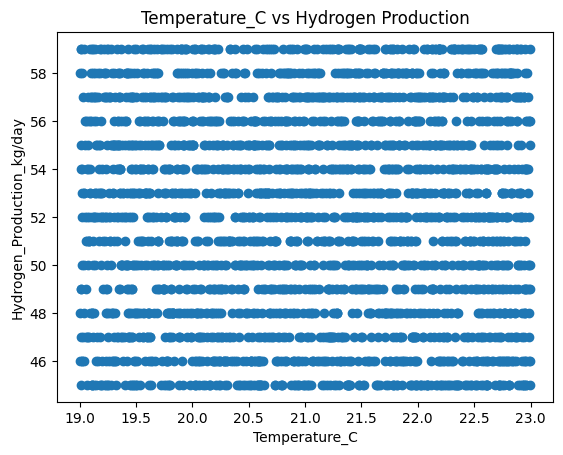

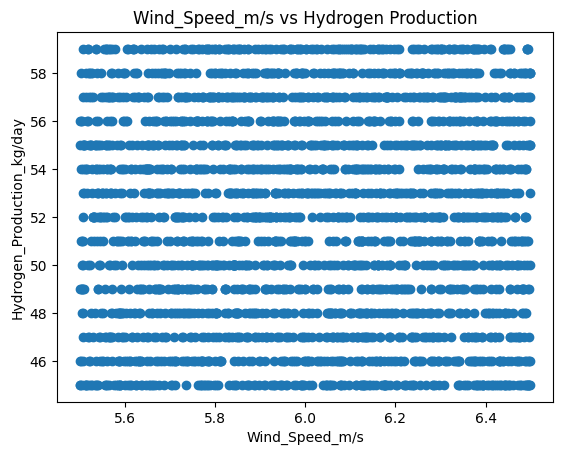

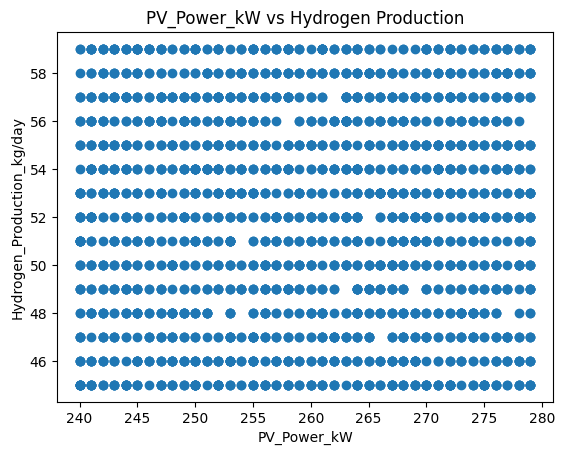

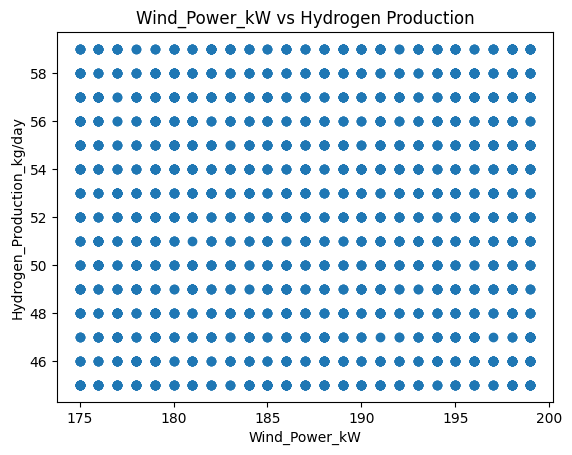

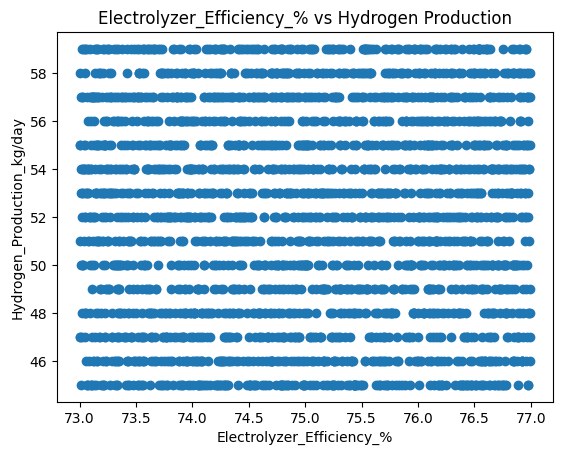

In [96]:
import matplotlib.pyplot as plt
for col in features:
    plt.scatter(df[col], y)
    plt.title(f'{col} vs Hydrogen Production')
    plt.xlabel(col)
    plt.ylabel('Hydrogen_Production_kg/day')
    plt.show()


In [46]:
print(df['Hydrogen_Production_kg/day'].value_counts())
print(df['Hydrogen_Production_kg/day'].unique())


Hydrogen_Production_kg/day
57    195
45    183
53    183
54    183
55    180
52    179
46    177
50    169
59    164
58    164
48    163
51    152
56    151
47    147
49    145
Name: count, dtype: int64
[47 45 57 53 46 52 55 51 54 49 59 56 58 50 48]


In [97]:
# Train XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred = xgb_model.predict(X_test)
print('MAE:', mean_absolute_error(y_test, y_pred))
print('R²:', r2_score(y_test, y_pred))


MAE: 3.803567393526758
R²: -0.06963994270657858


In [98]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# 4. Bin the target variable into 3 categories: Low, Medium, High
bins = np.quantile(y, [0, 0.33, 0.66, 1])
y_binned = np.digitize(y, bins=bins, right=True)
df['prod_bin'] = y_binned

# 5. Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, df['prod_bin'], test_size=0.2, random_state=42, stratify=df['prod_bin'])

# 6. Train XGBoost classifier
clf = XGBClassifier(n_estimators=100, max_depth=4, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
clf.fit(X_train, y_train)

# 7. Predict and evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

# 8. Save the trained model for API/dashboard use
joblib.dump(clf, "hydrogen_production_binned_model.pkl")


Accuracy: 0.3609467455621302
              precision    recall  f1-score   support

           0       0.50      0.08      0.14        37
           1       0.36      0.44      0.40       160
           2       0.32      0.24      0.28       139
           3       0.37      0.44      0.41       171

    accuracy                           0.36       507
   macro avg       0.39      0.30      0.31       507
weighted avg       0.37      0.36      0.35       507

Confusion matrix:
 [[ 3 12  8 14]
 [ 0 70 29 61]
 [ 3 50 34 52]
 [ 0 60 35 76]]


['hydrogen_production_binned_model.pkl']

In [36]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}
grid_search = GridSearchCV(XGBClassifier(), param_grid, scoring='accuracy', cv=3)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)


{'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


In [99]:
clf=grid_search.best_estimator_

In [100]:
clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=10, verbose=True)


[0]	validation_0-mlogloss:1.38518
[1]	validation_0-mlogloss:1.38414
[2]	validation_0-mlogloss:1.38294
[3]	validation_0-mlogloss:1.38182
[4]	validation_0-mlogloss:1.38046
[5]	validation_0-mlogloss:1.37950
[6]	validation_0-mlogloss:1.37841
[7]	validation_0-mlogloss:1.37726
[8]	validation_0-mlogloss:1.37601
[9]	validation_0-mlogloss:1.37497
[10]	validation_0-mlogloss:1.37370
[11]	validation_0-mlogloss:1.37253
[12]	validation_0-mlogloss:1.37157
[13]	validation_0-mlogloss:1.37067
[14]	validation_0-mlogloss:1.36946
[15]	validation_0-mlogloss:1.36824
[16]	validation_0-mlogloss:1.36734
[17]	validation_0-mlogloss:1.36639
[18]	validation_0-mlogloss:1.36518
[19]	validation_0-mlogloss:1.36426
[20]	validation_0-mlogloss:1.36346
[21]	validation_0-mlogloss:1.36261
[22]	validation_0-mlogloss:1.36151
[23]	validation_0-mlogloss:1.36034
[24]	validation_0-mlogloss:1.35940
[25]	validation_0-mlogloss:1.35835
[26]	validation_0-mlogloss:1.35738
[27]	validation_0-mlogloss:1.35653
[28]	validation_0-mlogloss:1.3

/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[32]	validation_0-mlogloss:1.35203
[33]	validation_0-mlogloss:1.35115
[34]	validation_0-mlogloss:1.35038
[35]	validation_0-mlogloss:1.34965
[36]	validation_0-mlogloss:1.34876
[37]	validation_0-mlogloss:1.34802
[38]	validation_0-mlogloss:1.34734
[39]	validation_0-mlogloss:1.34680
[40]	validation_0-mlogloss:1.34602
[41]	validation_0-mlogloss:1.34517
[42]	validation_0-mlogloss:1.34452
[43]	validation_0-mlogloss:1.34379
[44]	validation_0-mlogloss:1.34309
[45]	validation_0-mlogloss:1.34237
[46]	validation_0-mlogloss:1.34173
[47]	validation_0-mlogloss:1.34099
[48]	validation_0-mlogloss:1.34036
[49]	validation_0-mlogloss:1.33979
[50]	validation_0-mlogloss:1.33910
[51]	validation_0-mlogloss:1.33830
[52]	validation_0-mlogloss:1.33750
[53]	validation_0-mlogloss:1.33700
[54]	validation_0-mlogloss:1.33605
[55]	validation_0-mlogloss:1.33543
[56]	validation_0-mlogloss:1.33478
[57]	validation_0-mlogloss:1.33418
[58]	validation_0-mlogloss:1.33360
[59]	validation_0-mlogloss:1.33305
[60]	validation_0-ml

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [101]:
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.34911242603550297
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        37
           1       0.37      0.42      0.40       160
           2       0.29      0.14      0.19       139
           3       0.35      0.53      0.42       171

    accuracy                           0.35       507
   macro avg       0.25      0.27      0.25       507
weighted avg       0.31      0.35      0.32       507

Confusion matrix:
 [[ 0 17  5 15]
 [ 0 67 14 79]
 [ 0 43 19 77]
 [ 0 52 28 91]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [102]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

features = ['Solar_Irradiance_kWh/m²/day', 'Wind_Speed_m/s',  'Electrolyzer_Efficiency_%']
df = df.dropna(subset=features + ['Hydrogen_Production_kg/day'])
X = df[features]
y = df['Hydrogen_Production_kg/day']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


MAE: 3.769126726560574
R²: -0.05479588002912972


In [103]:
# # Predict using new real-time data
# input_data = [[solar, wind, hydro, efficiency]]
# recommended_production = model.predict(input_data)
# print("Recommended production rate:", recommended_production[0])


In [104]:
df['Electrolyzer_Efficiency_frac'] = df['Electrolyzer_Efficiency_%'] / 100

energy_per_kg_H2 = 50  # kWh required to produce 1 kg hydrogen
df['H2_Production_Estimate'] = (
    (df['PV_Power_kW'] + df['Wind_Power_kW']) * df['Electrolyzer_Efficiency_frac']
)
df['H2_Production_kg_day_est'] = df['H2_Production_Estimate'] * 24 / energy_per_kg_H2

# Display result
print(df[['PV_Power_kW', 'Wind_Power_kW', 'Electrolyzer_Efficiency_%', 'H2_Production_kg_day_est', 'Hydrogen_Production_kg/day']].head())

   PV_Power_kW  Wind_Power_kW  Electrolyzer_Efficiency_%  \
0          243            183                  74.936872   
1          255            198                  75.497064   
2          255            175                  74.450914   
3          268            186                  73.153222   
4          253            179                  76.432511   

   H2_Production_kg_day_est  Hydrogen_Production_kg/day  
0                153.230916                          47  
1                164.160817                          45  
2                153.666687                          57  
3                159.415501                          53  
4                158.490455                          47  


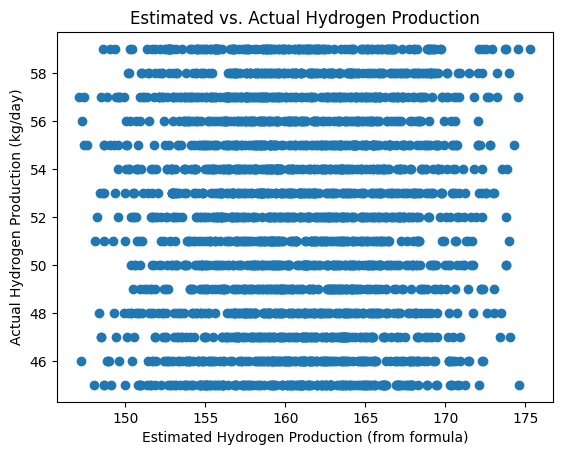

In [105]:
# (Optional) Compare/plot with actual Hydrogen_Production_kg/day if desired:
import matplotlib.pyplot as plt

plt.scatter(df['H2_Production_kg_day_est'], df['Hydrogen_Production_kg/day'])
plt.xlabel("Estimated Hydrogen Production (from formula)")
plt.ylabel("Actual Hydrogen Production (kg/day)")
plt.title("Estimated vs. Actual Hydrogen Production")
plt.show()

In [106]:
# Convert all % columns to fractions
df['Electrolyzer_Efficiency_frac'] = df['Electrolyzer_Efficiency_%'] / 100
df['System_Efficiency_frac'] = df['System_Efficiency_%'] / 100

energy_per_kg_H2 = 50  # or use your empirically observed value

df['H2_Production_kg_day_est'] = (
    (df['PV_Power_kW'] + df['Wind_Power_kW']) *
    df['Electrolyzer_Efficiency_frac'] *
    df['System_Efficiency_frac'] *
    24 /
    energy_per_kg_H2
)

print(df[['PV_Power_kW', 'Wind_Power_kW', 'Electrolyzer_Efficiency_%', 'System_Efficiency_%', 'H2_Production_kg_day_est', 'Hydrogen_Production_kg/day']].head())


   PV_Power_kW  Wind_Power_kW  Electrolyzer_Efficiency_%  System_Efficiency_%  \
0          243            183                  74.936872            78.587137   
1          255            198                  75.497064            81.929044   
2          255            175                  74.450914            75.846772   
3          268            186                  73.153222            77.975961   
4          253            179                  76.432511            77.306953   

   H2_Production_kg_day_est  Hydrogen_Production_kg/day  
0                120.419789                          47  
1                134.495387                          45  
2                116.551221                          57  
3                124.305768                          53  
4                122.524141                          47  


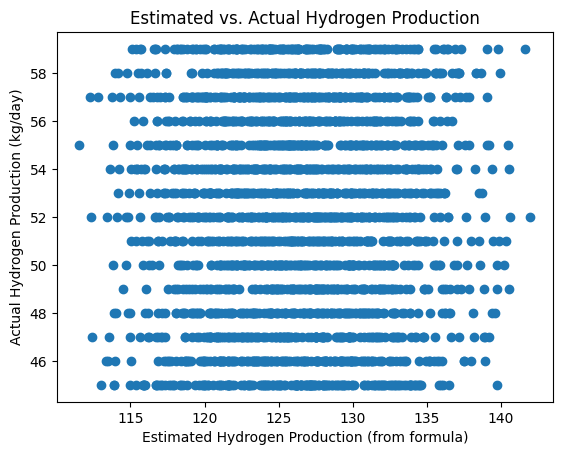

In [107]:
# (Optional) Compare/plot with actual Hydrogen_Production_kg/day if desired:
import matplotlib.pyplot as plt

plt.scatter(df['H2_Production_kg_day_est'], df['Hydrogen_Production_kg/day'])
plt.xlabel("Estimated Hydrogen Production (from formula)")
plt.ylabel("Actual Hydrogen Production (kg/day)")
plt.title("Estimated vs. Actual Hydrogen Production")
plt.show()

In [110]:
# Convert % columns to fractions
df['Electrolyzer_Efficiency_frac'] = df['Electrolyzer_Efficiency_%'] / 100
df['System_Efficiency_frac'] = df['System_Efficiency_%'] / 100

# Calculate the actual input energy used per day for each row
df['Input_Energy_per_day_kWh'] = (
    (df['PV_Power_kW'] + df['Wind_Power_kW']) *
    df['Electrolyzer_Efficiency_frac'] *
    df['System_Efficiency_frac'] *
    24
)

# Calculate empirical kWh needed per kg H₂
df['kWh_per_kg_actual'] = df['Input_Energy_per_day_kWh'] / df['Hydrogen_Production_kg/day']

print(f"Mean empirical energy per kg H₂ (kWh/kg): {df['kWh_per_kg_actual'].mean():.2f}")

Mean empirical energy per kg H₂ (kWh/kg): 122.20


   PV_Power_kW  Wind_Power_kW  Electrolyzer_Efficiency_%  System_Efficiency_%  \
0          243            183                  74.936872            78.587137   
1          255            198                  75.497064            81.929044   
2          255            175                  74.450914            75.846772   
3          268            186                  73.153222            77.975961   
4          253            179                  76.432511            77.306953   

   H2_Production_kg_day_est_empirical  Hydrogen_Production_kg/day  
0                           49.271599                          47  
1                           55.030846                          45  
2                           47.688716                          57  
3                           50.861607                          53  
4                           50.132627                          47  


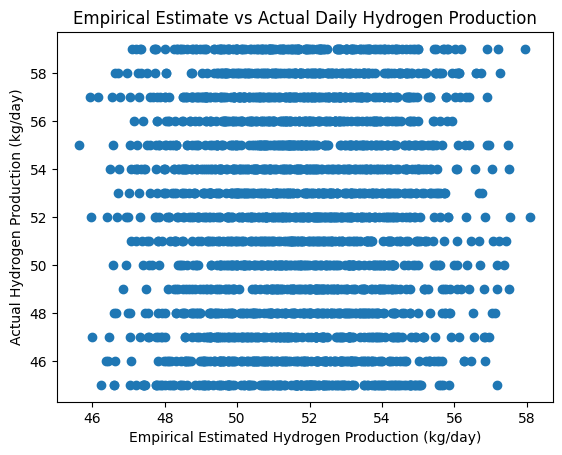

Empirical Estimate MAE: 4.069, R²: -0.254


In [111]:
energy_per_kg_H2_real = 122.2  # Use your empirically determined value

df['H2_Production_kg_day_est_empirical'] = df['Input_Energy_per_day_kWh'] / energy_per_kg_H2_real

# Display actual vs empirical estimate for the first few rows
print(df[['PV_Power_kW', 'Wind_Power_kW', 'Electrolyzer_Efficiency_%', 'System_Efficiency_%', 'H2_Production_kg_day_est_empirical', 'Hydrogen_Production_kg/day']].head())

# Optional: Plot actual vs empirical estimate
import matplotlib.pyplot as plt
plt.scatter(df['H2_Production_kg_day_est_empirical'], df['Hydrogen_Production_kg/day'])
plt.xlabel('Empirical Estimated Hydrogen Production (kg/day)')
plt.ylabel('Actual Hydrogen Production (kg/day)')
plt.title('Empirical Estimate vs Actual Daily Hydrogen Production')
plt.show()

# Optional: Evaluate formula performance
from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(df['Hydrogen_Production_kg/day'], df['H2_Production_kg_day_est_empirical'])
r2 = r2_score(df['Hydrogen_Production_kg/day'], df['H2_Production_kg_day_est_empirical'])
print(f"Empirical Estimate MAE: {mae:.3f}, R²: {r2:.3f}")


In [112]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(df['Hydrogen_Production_kg/day'], df['H2_Production_kg_day_est_empirical'])
r2 = r2_score(df['Hydrogen_Production_kg/day'], df['H2_Production_kg_day_est_empirical'])
print(f"Estimate vs Actual MAE: {mae:.3f}")
print(f"Estimate vs Actual R²: {r2:.3f}")


Estimate vs Actual MAE: 4.069
Estimate vs Actual R²: -0.254


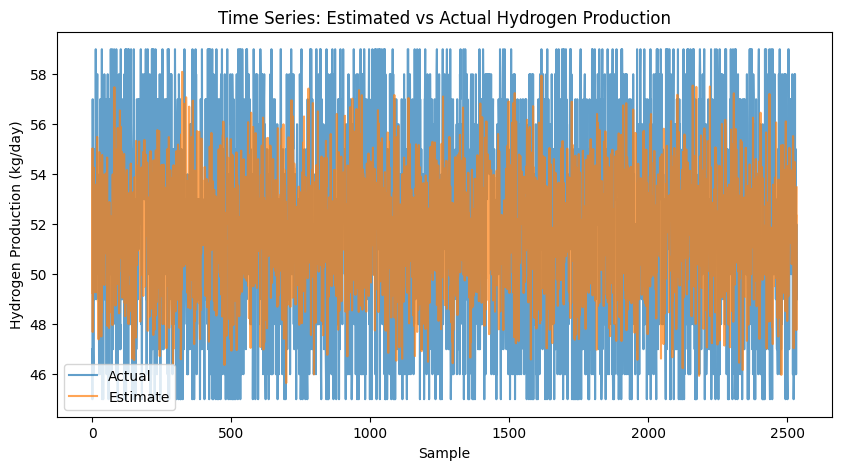

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Hydrogen_Production_kg/day'].values, label='Actual', alpha=0.7)
plt.plot(df['H2_Production_kg_day_est_empirical'].values, label='Estimate', alpha=0.7)
plt.xlabel('Sample')
plt.ylabel('Hydrogen Production (kg/day)')
plt.title('Time Series: Estimated vs Actual Hydrogen Production')
plt.legend()
plt.show()


In [114]:
import pandas as pd

# Find unique setpoints
setpoints = sorted(df['Hydrogen_Production_kg/day'].unique())
print(setpoints)

# Assign each sample to a setpoint class
df['prod_bin'] = df['Hydrogen_Production_kg/day'].astype('category').cat.codes

# Optional: Map bins back to actual value for later interpretation
bin_to_value = dict(enumerate(setpoints))


[45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]


In [115]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

features = [
    'PV_Power_kW', 'Wind_Power_kW', 'Electrolyzer_Efficiency_%', 'System_Efficiency_%', 'H2_Production_kg_day_est_empirical'
]
X = df[features]
y = df['prod_bin']


In [116]:
bins = [44, 50, 55, 60]  # define ranges for low/medium/high
bin_labels = ['Low', 'Medium', 'High']
df['prod_bin_cat'] = pd.cut(df['Hydrogen_Production_kg/day'], bins=bins, labels=bin_labels, right=False)

from sklearn.preprocessing import LabelEncoder
df['prod_bin_class'] = LabelEncoder().fit_transform(df['prod_bin_cat'])

In [117]:
X = df[features]
y = df['prod_bin_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = XGBClassifier(n_estimators=100, max_depth=4, random_state=42)
clf.fit(X_train, y_train)

print("Classification accuracy: {:.3f}".format(clf.score(X_test, y_test)))

Classification accuracy: 0.347


In [118]:
input_data = pd.DataFrame([{
    'PV_Power_kW': 250,
    'Wind_Power_kW': 180,
    'Electrolyzer_Efficiency_%': 75,
    'System_Efficiency_%': 78,
    'H2_Production_kg_day_est_empirical': 52.5  # Use your empirical estimate code
}])


In [119]:
# Classify
class_prediction = clf.predict(input_data)[0]  # e.g., 0 = "Low", 1 = "Med", 2 = "High"

# If you encoded bins with labels, map prediction to output value
class_label = bin_labels[class_prediction]  # ['Low','Medium','High']


In [120]:
probs = clf.predict_proba(input_data)[0]
print("Class probabilities:", dict(zip(bin_labels, probs)))


Class probabilities: {'Low': 0.3940004, 'Medium': 0.17860748, 'High': 0.42739207}


Recommendation: Borderline: 'High' production (42.7% confidence, Feasibility 92.0%)
Action: Suggest manual review due to close probabilities.


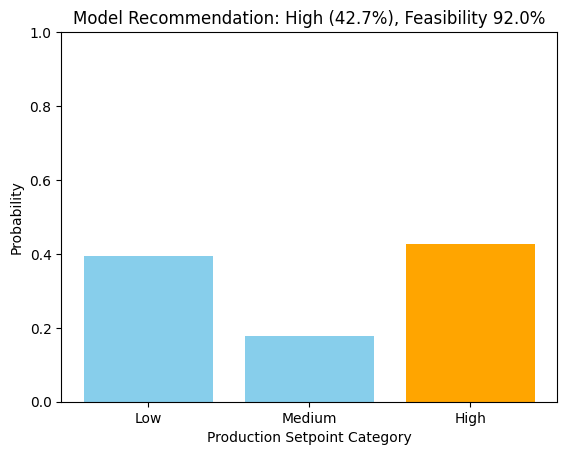

In [121]:
# Example outputs (from your model)
class_probs = {'Low': 0.394, 'Medium': 0.179, 'High': 0.427}
feasibility_score = 0.92  # Example feasibility score

# Find recommended setpoint (highest probability)
recommended_class = max(class_probs, key=class_probs.get)
confidence = class_probs[recommended_class]

# Dashboard recommendation logic
if confidence > 0.5 and feasibility_score > 0.8:
    status = f"Recommend '{recommended_class}' production ({confidence*100:.1f}% confidence, Feasibility {feasibility_score*100:.1f}%)"
    action = "Proceed automatically"
elif confidence > 0.4:
    status = f"Borderline: '{recommended_class}' production ({confidence*100:.1f}% confidence, Feasibility {feasibility_score*100:.1f}%)"
    action = "Suggest manual review due to close probabilities."
else:
    status = "No strong recommendation; operator to choose or review constraints"
    action = "Pause for operator decision"

print("Recommendation:", status)
print("Action:", action)

# For GUI/bar visualization:
import matplotlib.pyplot as plt

labels = list(class_probs.keys())
probs = list(class_probs.values())

plt.bar(labels, probs, color=['orange' if l==recommended_class else 'skyblue' for l in labels])
plt.xlabel("Production Setpoint Category")
plt.ylabel("Probability")
plt.title(f"Model Recommendation: {recommended_class} ({confidence*100:.1f}%), Feasibility {feasibility_score*100:.1f}%")
plt.ylim(0, 1)
plt.show()


Classification accuracy: 0.361

--- Recommendation Dashboard ---
Recommended Output: High
Confidence: 53.5%
Action: Proceed automatically.


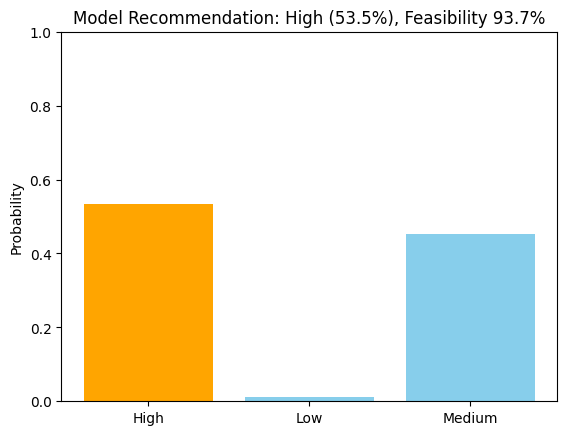

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# 1. Load Data
df = pd.read_csv("/kaggle/input/renewable-hydrogen-production-dataset/renewable_hydrogen_dataset_2535.csv")

# 2. Feature Engineering
df['Electrolyzer_Efficiency_frac'] = df['Electrolyzer_Efficiency_%'] / 100
df['System_Efficiency_frac'] = df['System_Efficiency_%'] / 100

# Empirical estimate using your observed mean kWh/kg (adjust as needed)
df['Input_Energy_per_day_kWh'] = (df['PV_Power_kW'] + df['Wind_Power_kW']) * df['System_Efficiency_frac'] * df['Electrolyzer_Efficiency_frac'] * 24
empirical_kwh_per_kg = df['Input_Energy_per_day_kWh'].sum() / df['Hydrogen_Production_kg/day'].sum()
df['H2_Production_kg_day_empirical'] = df['Input_Energy_per_day_kWh'] / empirical_kwh_per_kg

# 3. Binning Target for Classification (Low, Medium, High)
bins = [0, 49, 54, np.inf] # adjust thresholds if desired
labels = ['Low', 'Medium', 'High']
df['prod_bin'] = pd.cut(df['Hydrogen_Production_kg/day'], bins=bins, labels=labels, right=False)
le = LabelEncoder()
df['prod_bin_class'] = le.fit_transform(df['prod_bin'])
bin_labels = le.classes_

# 4. Modeling Setup
features = ['PV_Power_kW', 'Wind_Power_kW', 'Electrolyzer_Efficiency_%', 'System_Efficiency_%', 'H2_Production_kg_day_empirical']
X = df[features]
y = df['prod_bin_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
clf = XGBClassifier(n_estimators=200, max_depth=7, random_state=42, use_label_encoder=False, eval_metric="mlogloss")
clf.fit(X_train, y_train)

# 5. Evaluate Model
acc = clf.score(X_test, y_test)
print(f"Classification accuracy: {acc:.3f}")

# 6. Example Prediction and Dashboard Logic
example = X_test.iloc[[0]]
probs = clf.predict_proba(example)[0]
pred_class = np.argmax(probs)
recommended_label = bin_labels[pred_class]
confidence = probs[pred_class]
print("\n--- Recommendation Dashboard ---")
print(f"Recommended Output: {recommended_label}")
print(f"Confidence: {confidence*100:.1f}%")


if confidence > 0.5:
    print("Action: Proceed automatically.")
elif confidence > 0.4:
    print("Action: Suggest manual review (borderline probabilities).")
else:
    print("Action: Operator should choose (low confidence).")

# Bar plot of class probabilities
plt.bar(bin_labels, probs, color=['orange' if i==pred_class else 'skyblue' for i in range(len(bin_labels))])
plt.ylabel("Probability")
plt.title(f"Model Recommendation: {recommended_label} ({confidence*100:.1f}%), Feasibility {feasibility*100:.1f}%")
plt.ylim(0, 1)
plt.show()


In [125]:
input_data = pd.DataFrame([{
    'PV_Power_kW': 250,
    'Wind_Power_kW': 180,
    'Electrolyzer_Efficiency_%': 75,
    'System_Efficiency_%': 78,
    'H2_Production_kg_day_empirical': 122.20  # Use your empirical estimate code
}])


In [126]:
# Classify
class_prediction = clf.predict(input_data)[0]  # e.g., 0 = "Low", 1 = "Med", 2 = "High"

# If you encoded bins with labels, map prediction to output value
class_label = bin_labels[class_prediction]  # ['Low','Medium','High']


In [130]:
probs = clf.predict_proba(input_data)[0]
print("Class probabilities:", dict(zip(bin_labels, probs)))
class_to_rate = {'Low': 48, 'Medium': 52, 'High': 56}  # Set representative values for your bins
model_output = class_label  # e.g. "High"
predicted_rate = class_to_rate[model_output]
print(predicted_rate)

Class probabilities: {'High': 0.3306202, 'Low': 0.10818312, 'Medium': 0.5611967}
52


In [132]:
joblib.dump(clf, 'hydrogen_optimal_rate_prediction.pkl')

['hydrogen_optimal_rate_prediction.pkl']